In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.neural_network import MLPClassifier

import seaborn as sns
import matplotlib.pyplot as plt

## Dataset

Season long stat-sheets for 1339 NBA rookies with the binary classification of whether career lasted at least 5 years.

Source: https://data.world/exercises/logistic-regression-exercise-1


In [2]:
df = pd.read_csv('nba_rookies.csv')

#Players with no 3-pt attempts are assumed to have a 3P% of one stdev. below mean
assumedPercentage = df['3P%'].mean() - df['3P%'].std()
df['3P%'].fillna(assumedPercentage, inplace=True)

df.head(3)

,Name,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0.0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0.0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0.0


## Training/Testing Split

Data is split to be 30% testing data and 70% training data

In [3]:
X, y = df.loc[:,'GP':'TOV'], df['TARGET_5Yrs']
y = y.astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Decision Tree

Decision trees of differing depths are fit and accuracy of predicting test data is compared

In [4]:
dtmaxacc = 0
for x in [2,5,10,15,20]:
    decision_tree = tree.DecisionTreeClassifier(random_state=0, max_depth=x)
    decision_tree = decision_tree.fit(X_train, y_train)
    acc = decision_tree.score(X_test, y_test)
    print('depth: ' + str(x) + ', accuracy: '+ str(acc))
    if acc > dtmaxacc: dtmaxacc = acc

depth: 2, accuracy: 0.6442786069651741
depth: 5, accuracy: 0.6194029850746269
depth: 10, accuracy: 0.5920398009950248
depth: 15, accuracy: 0.6119402985074627
depth: 20, accuracy: 0.6169154228855721


## K-Nearest Neighbors

KNN models of differing numbers of neighbors are fit and accuracy of predicting test data is compared

In [5]:
knnmaxacc = 0
for x in [1,2,3,5,8]:
    neigh = KNeighborsClassifier(n_neighbors=x)
    neigh.fit(X_train, y_train)
    acc = neigh.score(X_test, y_test)
    print('n-neighbors: ' + str(x) + ', accuracy: '+ str(acc))
    if acc > knnmaxacc: knnmaxacc = acc

n-neighbors: 1, accuracy: 0.6368159203980099
n-neighbors: 2, accuracy: 0.6119402985074627
n-neighbors: 3, accuracy: 0.6741293532338308
n-neighbors: 5, accuracy: 0.6890547263681592
n-neighbors: 8, accuracy: 0.7114427860696517


## Naive Bayes

Gaussian Naive Bayes models of differing amounts of smoothing are fit and accuracy of predicting test data is compared

In [6]:
nbmaxacc = 0
for x in [-6,-4,-2,-1]:
    naive_bayes = GaussianNB(var_smoothing = 10**x)
    naive_bayes = naive_bayes.fit(X_train, y_train)
    acc = naive_bayes.score(X_test, y_test)
    print('smoothing: 1e' + str(x) + ', accuracy: '+ str(acc))
    if acc > nbmaxacc: nbmaxacc = acc

smoothing: 1e-6, accuracy: 0.6417910447761194
smoothing: 1e-4, accuracy: 0.6393034825870647
smoothing: 1e-2, accuracy: 0.6840796019900498
smoothing: 1e-1, accuracy: 0.6915422885572139


## Support Vector Machines

Support vector machine models of differing kernel types are fit and accuracy of predicting test data is compared

In [7]:
svmmaxacc = 0
for x in ['linear', 'poly', 'rbf', 'sigmoid']:
    s_v_m = svm.SVC(kernel=x)
    s_v_m = s_v_m.fit(X_train, y_train)
    acc = s_v_m.score(X_test, y_test)
    print('kernel type: ' + str(x) + ', accuracy: '+ str(acc))
    if acc > svmmaxacc: svmmaxacc = acc

kernel type: linear, accuracy: 0.7313432835820896
kernel type: poly, accuracy: 0.6940298507462687
kernel type: rbf, accuracy: 0.7064676616915423
kernel type: sigmoid, accuracy: 0.43781094527363185


## Multi-Layer Perceptron

Multi-layer perceptron models of differing numbers of hidden layers are fit and accuracy of predicting test data is compared

In [9]:
mlpmaxacc = 0
for x in [(5,), (10,), (50,), (100,), (700,)]:
    mlp = MLPClassifier(random_state=1, max_iter=800, hidden_layer_sizes = x)
    mlp = mlp.fit(X_train, y_train)
    acc = mlp.score(X_test, y_test)
    print('# of hidden layers: ' + str(x[0]) + ', accuracy: '+ str(acc))
    if acc > mlpmaxacc: mlpmaxacc = acc

# of hidden layers: 5, accuracy: 0.6990049751243781
# of hidden layers: 10, accuracy: 0.7238805970149254
# of hidden layers: 50, accuracy: 0.6766169154228856
# of hidden layers: 100, accuracy: 0.7014925373134329
# of hidden layers: 700, accuracy: 0.6965174129353234


## Highest Accuracy Attained from Each Algorithm

A simple barplot to compare the highest accuracy score attained from each algorithm

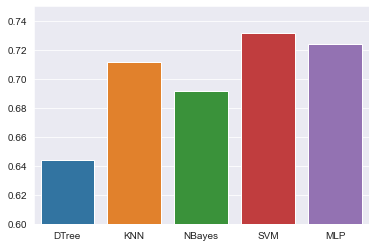

In [10]:
max_accuracy = [dtmaxacc, knnmaxacc, nbmaxacc, svmmaxacc, mlpmaxacc]
algorithms = ['DTree', 'KNN', 'NBayes', 'SVM', 'MLP']

sns.set_style('darkgrid')
sns.barplot(x = algorithms, y = max_accuracy)
plt.ylim(.6, .75)
plt.show()